<a href="https://colab.research.google.com/github/gnganesh99/NN_Error/blob/ayush_dev/notebooks/STM/stm_multiscale_loss_vs_scale.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Installs on colab
def running_on_colab():
    try:
        import google.colab  # type: ignore
        return True
    except ImportError:
        return False

if running_on_colab():
    print("Running on Colab. Installing dependencies...")
    !pip install -q atomai neuraloperator ipympl ipywidgets hoffmanstmpy

    from google.colab import output
    output.enable_custom_widget_manager()

    !git clone -b ayush_dev --single-branch https://github.com/gnganesh99/NN_Error.git
    %cd NN_Error

    print("Colab setup complete.")

Running on Colab. Installing dependencies...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 kB 19.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.0/179.0 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.6/248.6 kB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.0/519.0 kB 46.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 145.3/145.3 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 291.2/291.2 kB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 124.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.3/59.3 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 147.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.8/174.8 kB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import sys
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset
import os
from scipy.ndimage import zoom


try:
    get_ipython().run_line_magic("matplotlib", "widget")
except (ValueError, RuntimeError):
    get_ipython().run_line_magic("matplotlib", "inline")
import matplotlib.pyplot as plt


# Make package and notebook-local helper modules importable whether this starts in repo root or notebooks/
repo_root = Path.cwd() if (Path.cwd() / "src" / "nnerror").exists() else Path.cwd().parent.parent
src_root = str((repo_root / "src").resolve())
nb_root = str((repo_root / "notebooks"/"STM").resolve())
for import_root in (src_root, nb_root):
    if import_root not in sys.path:
        sys.path.insert(0, import_root)




from nnerror.networks import FNO_im2spec, CustomDecoder, im2spec, im2spec_attn
from nnerror.training_functions import err_estimation, train_model, predict_spectra, norm_0to1, predict_posterior, append_training_set
from nnerror.plot_functions import plot_only_training_loss, plot_training_loss, \
    plot_error_prediction, plot_spectra, plot_error_prediction_3d, plot_scale_slider, plot_latent_space, cluster_latent_space, plot_latent_distribution, plot_scale_specific_error_and_acquisition_maps
from nnerror.utils import append_multiscale_data, edges_zeroed_image, interpolated_center_crop, paired_images_spectra_1
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [3]:
from stm_utils import Sxm_Image
from CITS_Class import CITS_Analysis


In [17]:
class Norm_G:
    """Gaussian normalization using mean and standard deviation."""

    def __init__(self, data=None, mean=None, std=None, axis=0, eps=1e-8):
        self.data = data
        self.axis = axis
        self.eps = eps

        if data is not None:
            self.mean = np.mean(data, axis=axis, keepdims=True)
            self.std = np.std(data, axis=axis, keepdims=True)
        elif mean is not None and std is not None:
            self.mean = mean
            self.std = std
        else:
            raise ValueError("Either data or both mean and std must be provided.")

        self.std = np.where(self.std < eps, eps, self.std)

    def normalize(self, data=None):
        """Normalize data using stored mean and std."""
        if data is None:
            data = self.data
        return (data - self.mean) / self.std

    def denormalize(self, normalized_data):
        """Denormalize data using stored mean and std."""
        return normalized_data * self.std + self.mean


class Norm_0to1:
    """Normalization to the range [0, 1]."""

    def __init__(self, data=None, min_val=None, max_val=None, axis=0, eps=1e-8):
        self.data = data
        self.axis = axis
        self.eps = eps

        if data is not None:
            self.min_val = np.min(data, axis=axis, keepdims=True)
            self.max_val = np.max(data, axis=axis, keepdims=True)
        elif min_val is not None and max_val is not None:
            self.min_val = min_val
            self.max_val = max_val
        else:
            raise ValueError("Either data or both min_val and max_val must be provided.")

        self.data_range = np.where(
            (self.max_val - self.min_val) < eps,
            eps,
            self.max_val - self.min_val
        )

    def normalize(self, data=None):
        """Normalize data using stored min and max."""
        if data is None:
            if self.data is None:
                raise ValueError("No data provided to normalize.")
            data = self.data

        return (data - self.min_val) / self.data_range

    def denormalize(self, normalized_data):
        """Denormalize data using stored min and max."""
        return normalized_data * self.data_range + self.min_val

# Get data

In [4]:
data_folder = r"data/large_area" if not running_on_colab() else r"notebooks/STM/data/large_area"

img_sxm = os.path.join(data_folder, "EnZn2As2017.sxm")
spectra_sxm = os.path.join(data_folder, "EuZn2As2003.3ds")
#Get the morphology image
full_image = Sxm_Image(img_sxm).image()
full_image = norm_0to1(full_image)

#Get the current spectra
cits_obj = CITS_Analysis(spectra_sxm)
hyperspectra = cits_obj.current

full_image.shape, hyperspectra.shape

File import successful.


((512, 512), (80, 250, 121))

In [5]:
WS = 32
WS_init = 4
d_WS = 4
n_epochs_im2spec = 200
n_epochs_error = 200
error_type = "L1" # "L1", "L2", or "cos"
model_type = 'im2spec'
append_image_type = "pad" if model_type == 'im2spec' or 'im2spec_attn' else "interpolate" #pad, interpolate
use_swa = True
latent_dim = 5
last_swa_epochs = 100

(1024, 32, 32) (1024, 121) (1024, 2)
[30. 30.]


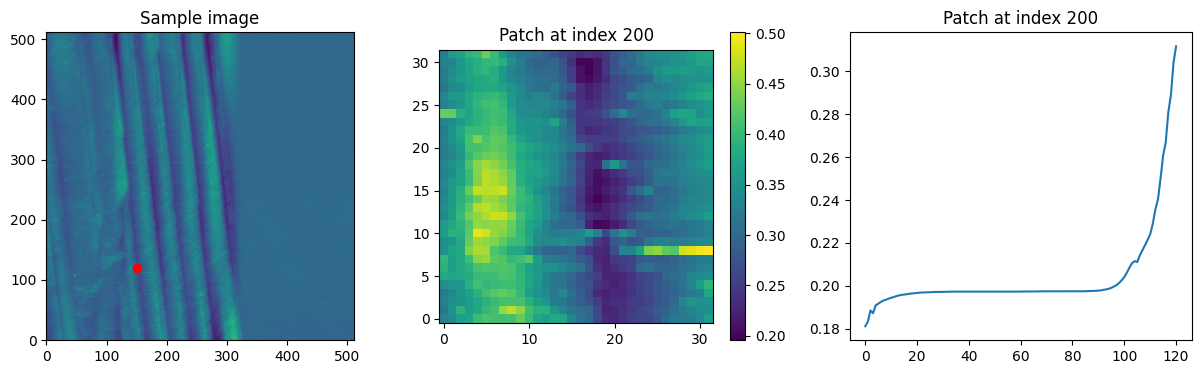

In [6]:


images, spectra, coordinates = paired_images_spectra_1(full_image, cits_obj, hyperspectra, window_size = WS,
                                                       coordinate_step = 15, image_norm=False, spectra_norm = False)

print(images.shape, spectra.shape, coordinates.shape)

print(coordinates[0])
fig, ax = plt.subplots(1, 3, figsize = (15, 4))


idx = 200

ax[0].imshow(full_image, origin = 'lower')
ax[0].scatter(coordinates[idx, 1], coordinates[idx, 0], c ="r")
ax[0].set_title("Sample image")


im = ax[1].imshow(images[idx], origin = 'lower')
fig.colorbar(im, ax=ax[1])
ax[1].set_title(f"Patch at index {idx}")
ax[2].plot(spectra[idx])
ax[2].set_title(f"Patch at index {idx}")

plt.show()

In [7]:
# coordinates are reversed.
swap_coordinates = coordinates.copy()
swap_coordinates = swap_coordinates[:, [1, 0]]
swap_coordinates.shape

(1024, 2)

## Train/test split

In [8]:
images_all = images.copy()
spectra_all = spectra.copy()
swap_coordinates_all = swap_coordinates.copy()

In [9]:
from sklearn.model_selection import train_test_split

images_train, images_test, spectra_train, spectra_test, s_coords_train, s_coords_test = train_test_split(
images_all, spectra_all, swap_coordinates_all, test_size = 0.2, random_state=42
)

initial_trainsize = images_train.shape[0]
print("images_train shape:", images_train.shape)
print("images_test shape:", images_test.shape)
print("spectra_train shape:", spectra_train.shape)
print("spectra_test shape:", spectra_test.shape)

images_train shape: (819, 32, 32)
images_test shape: (205, 32, 32)
spectra_train shape: (819, 121)
spectra_test shape: (205, 121)


## Augment across scales

In [10]:
images, spectra, scale_coordinates = append_multiscale_data(images_all, spectra_all, scales=np.arange(WS_init, WS, d_WS),
                                                            coordinates=swap_coordinates_all,
                                                            append_image_type=append_image_type)

Augmented images shape: (8192, 32, 32), Augmented spectra shape: (8192, 121), Augmented coordinates shape: (8192, 3)


In [11]:
images_tr_aug, spectra_tr_aug, _ = append_multiscale_data(images_train, spectra_train, scales=np.arange(WS_init, WS, d_WS),
                                                            coordinates=s_coords_train,
                                                            append_image_type=append_image_type)



images_test_aug, spectra_test_aug, _ = append_multiscale_data(images_test, spectra_test, scales=np.arange(WS_init, WS, d_WS),
                                                            coordinates=s_coords_test,
                                                            append_image_type=append_image_type)

print("images_train shape:", images_tr_aug.shape)
print("images_test shape:", images_test_aug.shape)

Augmented images shape: (6552, 32, 32), Augmented spectra shape: (6552, 121), Augmented coordinates shape: (6552, 3)
Augmented images shape: (1640, 32, 32), Augmented spectra shape: (1640, 121), Augmented coordinates shape: (1640, 3)
images_train shape: (6552, 32, 32)
images_test shape: (1640, 32, 32)


## Model dimensions

In [12]:

print("images shape:", images.shape)
print("spectra shape:", spectra.shape)
in_dim = images[0].shape  # Input dimensions (image height and width)
out_dim = len(spectra[0])  # Output dimensions (spectra length)

images shape: (8192, 32, 32)
spectra shape: (8192, 121)


# Train im2spec

## IM2SPEC model

In [13]:
# ----------------------------
# 2) Fit FNO_im2spec model
# ----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if model_type == 'FNO':

  # FNO_im2spec mode. Trains better with interpolation based augmentation.
  imspec_model = FNO_im2spec(
      target_size=out_dim,
      latent_dim=latent_dim,
      hidden_channels=32,
      n_modes=(16, 16),
      n_layers=4,
      use_swa = use_swa,
      last_swa_epochs = last_swa_epochs,
  ).to(device)

elif model_type == 'im2spec':
  # Use this normal im2spec. Augmentation by padding works better here.
  imspec_model = im2spec(feature_size=in_dim, target_size=out_dim, latent_dim=latent_dim).to(device)
elif model_type == 'im2spec_attn':
  imspec_model = im2spec_attn(feature_size=in_dim, target_size=out_dim, latent_dim=latent_dim).to(device)



else:
  raise ValueError(f"Unknown model type: {model_type}")


 50%|█████     | 101/200 [03:02<02:58,  1.80s/it, train_loss=0.0011, val_loss=0.0019]

SWA triggered at epoch 100


 57%|█████▊    | 115/200 [03:29<02:35,  1.83s/it, train_loss=0.0010, val_loss=0.0020]


Early stopping triggered after 10 epochs!


/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:85: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:89: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  parser.resetCache()
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2010: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
  p.space          = oneOf(self._space_widths)("space")
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2020: PyparsingDeprecationWarning: 'leaveWhitespace' deprecated - use 'leave_whitespace'
  )("sym").leaveWhitespace()
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:1984: PyparsingDeprecationWarning: 'setName' deprecated - use 'set_name'
  val.setName(key)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:1987: PyparsingDeprecationWarning: 'setParseA

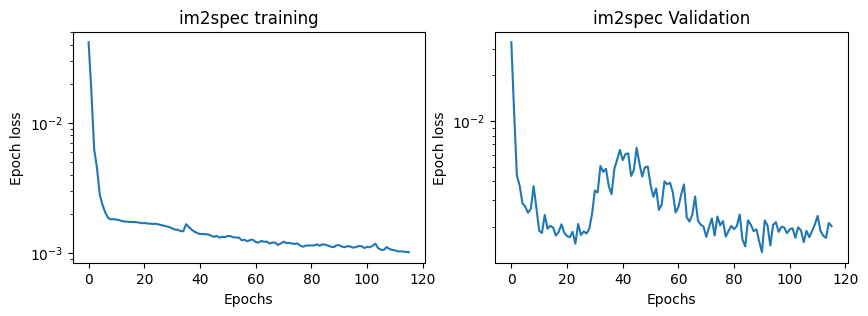

im2spec final train loss: 0.001009175165866812
im2spec final internal val loss: 0.002023196662776172
im2spec held-out test loss: 0.0025585531257092953


In [14]:


im2spec_training_dataset = TensorDataset(
    torch.tensor(images_tr_aug, dtype=torch.float32),
    torch.tensor(spectra_tr_aug, dtype=torch.float32),
)

im2spec_val_dataset = TensorDataset(
    torch.tensor(images_test_aug, dtype=torch.float32),
    torch.tensor(spectra_test_aug, dtype=torch.float32),
)

# train_model creates its own validation split from the dataset above.
# Keep images_test/spectra_test as an external held-out test set.

plot_im2spec_training = True

imspec_model, im2spec_train_loss, im2spec_val_loss = train_model(
    imspec_model,
    im2spec_training_dataset,
    n_batches=6,
    lr=1e-3,
    patience=10,
    n_epochs=n_epochs_im2spec,
    partial_train=False,
    val_dataset=im2spec_val_dataset,  # if not provided, train_model will split off its own validation set from the training dataset
    use_swa = True,
    last_swa_epochs = last_swa_epochs
)

if plot_im2spec_training:
    plot_only_training_loss([im2spec_train_loss], [im2spec_val_loss])

imspec_model.eval()
with torch.no_grad():
    x_test = torch.tensor(images_test, dtype=torch.float32, device=device)
    y_test = torch.tensor(spectra_test, dtype=torch.float32, device=device)
    test_pred = imspec_model.predict(x_test)
    im2spec_test_loss = torch.nn.functional.mse_loss(test_pred, y_test).item()

print("im2spec final train loss:", im2spec_train_loss[-1])
print("im2spec final internal val loss:", im2spec_val_loss[-1])
print("im2spec held-out test loss:", im2spec_test_loss)


# Estimate error

In [18]:
# ----------------------------
# 3) Build error targets using err_estimation
# ----------------------------
error_mean, error_std, error_vector = err_estimation(imspec_model, images_tr_aug, spectra_tr_aug, error_type=error_type)
error_targets = error_mean.astype(np.float32).reshape(-1, 1)
error_norm = Norm_0to1(data=error_targets)
normed_error_targets = error_norm.normalize()


print("error_mean shape:", error_mean.shape)
print("error_vector shape:", error_vector.shape)
print("error_targets shape:", error_targets.shape)


# ----------------------------
# 4) Fuse im2spec encoder with CustomDecoder
# ----------------------------
with torch.no_grad():
    latent_dim = imspec_model.encoder(torch.tensor(images[:1], dtype=torch.float32, device=device).unsqueeze(1)).shape[1]

error_model = CustomDecoder(encoder=imspec_model.encoder, embed_dim=latent_dim, target_size=1).to(device)

error_mean shape: (6552,)
error_vector shape: (6552, 121)
error_targets shape: (6552, 1)


## Train error model

 50%|█████     | 101/200 [02:04<02:02,  1.24s/it, train_loss=0.0003, val_loss=0.0002]

SWA triggered at epoch 100


 64%|██████▍   | 129/200 [02:40<01:28,  1.24s/it, train_loss=0.0002, val_loss=0.0002]
/tmp/ipykernel_1548/1515650117.py:29: UserWarning: Using a target size (torch.Size([6552])) that is different to the input size (torch.Size([1640, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  error_test_loss = torch.nn.functional.mse_loss(test_pred_error, y_test_error).item()


Early stopping triggered after 10 epochs!
error model final train loss: 0.00017598256766047728
error model final val loss: 0.00019727407821587155
error model held-out test loss: 0.00026173455989919603


/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
/usr/local/lib/python3.12/dist-packages/pyparsing/util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2178: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  ParserElement.resetCache()


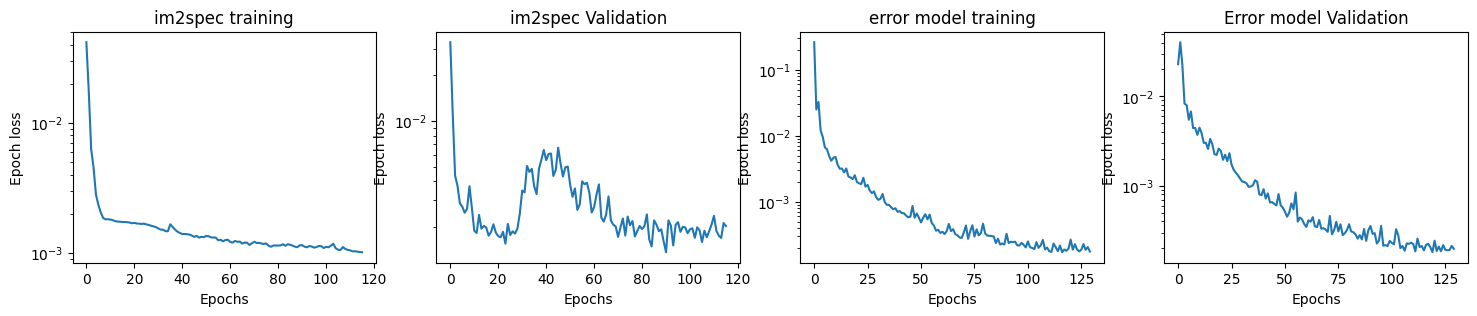

In [19]:

# ----------------------------
# 5) Train error model on images and estimated errors
# ----------------------------



error_training_dataset = TensorDataset(
    torch.tensor(images_tr_aug, dtype=torch.float32),
    torch.tensor(error_targets, dtype=torch.float32),
)


error_model, error_train_loss, error_val_loss = train_model(
    error_model,
    error_training_dataset,
    n_batches=6,
    lr=1e-3,
    patience=10,
    n_epochs=n_epochs_error,
    partial_train=True,
    use_swa = True,
    last_swa_epochs = last_swa_epochs
)
error_model.eval()
with torch.no_grad():
    x_test_error = torch.tensor(images_test_aug, dtype=torch.float32, device=device)
    y_test_error = torch.tensor(error_mean, dtype=torch.float32, device=device)
    test_pred_error = error_model.predict(x_test_error)
    error_test_loss = torch.nn.functional.mse_loss(test_pred_error, y_test_error).item()

print("error model final train loss:", error_train_loss[-1])
print("error model final val loss:", error_val_loss[-1])
print("error model held-out test loss:", error_test_loss)

plot_training_loss([im2spec_train_loss], [im2spec_val_loss], error_train_loss, error_val_loss)

# Predict all errors

In [20]:
#Predict errors on the entire dataset using the trained error model
predicted_errors = predict_spectra(error_model, images, ensemble=False)
predicted_errors = np.clip(predicted_errors, 0, None)
print("predicted_errors shape:", np.asarray(predicted_errors).shape)
print("predicted_errors range:", float(np.min(predicted_errors)), float(np.max(predicted_errors)))

predicted_errors shape: (8192,)
predicted_errors range: 0.0 0.11417722702026367


# Acquisition Function

In [21]:
import pandas as pd

# grouping
df_errors = pd.DataFrame({
    'x': scale_coordinates[:, 0],
    'y': scale_coordinates[:, 1],
    'scale': scale_coordinates[:, 2],
    'error': predicted_errors,
    'original_index': np.arange(len(predicted_errors)) # Store original indices
})

# x,y grouping by error
# idx min gets the index of the points with min error in the scale
# then get full row with x and y coords.
min_errors_df = df_errors.loc[df_errors.groupby(['x', 'y'])['error'].idxmin()].reset_index(drop=True)

# relevant columns, including the original_index for mapping back
min_errors_xy = min_errors_df[['x', 'y', 'scale','error', 'original_index']]

print("Minimum error for each (x, y) coordinate:")
display(min_errors_xy.head())

print("Shape of min_errors_xy (x, y, min_error, original_index):")
print(min_errors_xy.shape)

Minimum error for each (x, y) coordinate:


,x,y,scale,error,original_index
0,30.0,30.0,8.0,0.015386,1024
1,30.0,45.0,8.0,0.017519,1056
2,30.0,60.0,8.0,0.013915,1088
3,30.0,75.0,8.0,0.017471,1120
4,30.0,90.0,8.0,0.018428,1152


Shape of min_errors_xy (x, y, min_error, original_index):
(1024, 5)


In [22]:
# Calculate aq_fn for the entire dataset based on min_errors_xy
from nnerror.training_functions import distance_acq_fn

aq_ind, aq_fn = distance_acq_fn(min_errors_xy['error'].values,
                                beta=0,
                                lambda_=1,
                                sample_next_points=len(min_errors_xy), # Get values for all
                                exclude_indices=[])
print("Shape of aq_fn:", aq_fn.shape)


Shape of aq_fn: (1024,)


In [23]:
from nnerror.training_functions import distance_acq_fn, append_training_set, train_model, err_estimation, predict_spectra
from nnerror.plot_functions import plot_error_prediction, plot_spectra, plot_error_prediction_3d
from nnerror.networks import CustomDecoder # Assuming CustomDecoder is needed for error_model retraining
from sklearn.model_selection import train_test_split # Added import for train_test_split


#al denotes variables used for active learning

# initialize variables for the acquisition loop
acquisition_iterations = 5  # number of iterations
num_new_points = 10  # points per iteration

error_log = [] # reinitialize error_log for tracking

# storing losses
im2spec_al_train_losses = []
im2spec_al_val_losses = []
error_al_train_losses = []
error_al_val_losses = []


# original indices for the full dataset
original_indices = np.arange(len(images))

# aqn function for all available x,y locations
_, initial_aq_fn_values_all = distance_acq_fn(min_errors_xy['error'].values,
                                                beta=0,
                                                lambda_=1,
                                                sample_next_points=len(min_errors_xy), # Get values for all
                                                exclude_indices=[])

# initialize training set as empty array
current_images_train = np.empty((0, images.shape[1], images.shape[2]), dtype=images.dtype)
current_spectra_train = np.empty((0, spectra.shape[1]), dtype=spectra.dtype)
current_indices_train = np.empty((0,), dtype=np.int64)

#redo test train split to ensure there is something in the train set initially

#all available original indices
all_available_indices = min_errors_xy['original_index'].values

#
initial_train_indices, _ = train_test_split(
    all_available_indices, test_size=0.9, random_state=42
)

for next_index in initial_train_indices:
    current_images_train, current_spectra_train, current_indices_train = append_training_set(
        images, spectra, next_index, current_images_train, current_spectra_train, current_indices_train
    )


for i in range(acquisition_iterations):
    print(f"\nActive Learning Iteration {i+1}/{acquisition_iterations}")

    # ensuring that the same point does not get selected
    # filter out points whose original_index is already in current_indices_train
    available_min_errors_xy = min_errors_xy[~min_errors_xy['original_index'].isin(current_indices_train)]

    if len(available_min_errors_xy) == 0:
        print(f"No more points to acquire after {i} iterations.")
        break

    aq_ind_df, _ = distance_acq_fn(available_min_errors_xy['error'].values,
                                            beta=0,
                                            lambda_=1,
                                            sample_next_points=num_new_points,
                                            exclude_indices=[])

    # get original indices of the new points
    newly_acquired_original_indices = available_min_errors_xy.iloc[aq_ind_df]['original_index'].values

    # use the append_training_set function for each newly acquired point
    for next_index in newly_acquired_original_indices:
        current_images_train, current_spectra_train, current_indices_train = append_training_set(
            images, spectra, next_index, current_images_train, current_spectra_train, current_indices_train
        )

    # error of new points for logging
    new_images = images[newly_acquired_original_indices]
    new_spectra = spectra[newly_acquired_original_indices]

    error_mean_new_points, _, _ = err_estimation(imspec_model, new_images, new_spectra, error_type=error_type)
    error_log.append(error_mean_new_points.mean())


    # recreate datasets
    im2spec_al_training_dataset = TensorDataset(
        torch.tensor(current_images_train, dtype=torch.float32),
        torch.tensor(current_spectra_train, dtype=torch.float32),
    )

    # validation dataset
    im2spec_al_val_dataset = TensorDataset(
        torch.tensor(images_test_aug, dtype=torch.float32),
        torch.tensor(spectra_test_aug, dtype=torch.float32),
    )

    # retrain imspec_model
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    if model_type == 'FNO':
        imspec_model = FNO_im2spec(
            target_size=out_dim,
            latent_dim=latent_dim,
            hidden_channels=32,
            n_modes=(16, 16),
            n_layers=4,
        ).to(device)
    elif model_type == 'im2spec':
        imspec_model = im2spec(feature_size=in_dim, target_size=out_dim, latent_dim=latent_dim).to(device)
    elif model_type == 'im2spec_attn':
        imspec_model = im2spec_attn(feature_size=in_dim, target_size=out_dim, latent_dim=latent_dim).to(device)
    else:
        raise ValueError(f"Unknown model type: {model_type}")

    imspec_model, al_im2spec_train_loss, al_im2spec_val_loss = train_model(
        imspec_model,
        im2spec_al_training_dataset,
        n_batches=6,
        lr=1e-3,
        patience= 10,
        n_epochs=n_epochs_im2spec // 5, #reduced epochs for faster retraining
        partial_train=False,
        val_dataset=im2spec_al_val_dataset,
        use_swa=True,
        last_swa_epochs = 0.1
    )
    im2spec_al_train_losses.append(al_im2spec_train_loss[-1])
    im2spec_al_val_losses.append(al_im2spec_val_loss[-1])

    # estimate errors again with the appended dataset
    error_mean_al, _, _ = err_estimation(imspec_model, current_images_train, current_spectra_train, error_type=error_type)
    error_targets_al = error_mean_al.astype(np.float32).reshape(-1, 1)

    # retrain and reinitialize error model
    with torch.no_grad():
        latent_dim = imspec_model.encoder(torch.tensor(images[:1], dtype=torch.float32, device=device).unsqueeze(1)).shape[1]
    error_model = CustomDecoder(encoder=imspec_model.encoder, embed_dim=latent_dim, target_size=1).to(device)

    error_al_training_dataset = TensorDataset(
        torch.tensor(current_images_train, dtype=torch.float32),
        torch.tensor(error_targets_al, dtype=torch.float32),
    )

    # test set errors to evaluate error model
    error_mean_test_al, _, _ = err_estimation(imspec_model, images_test_aug, spectra_test_aug, error_type=error_type)
    error_targets_test_al = error_mean_test_al.astype(np.float32).reshape(-1, 1)

    error_al_val_dataset = TensorDataset(
        torch.tensor(images_test_aug, dtype=torch.float32),
        torch.tensor(error_targets_test_al, dtype=torch.float32),
    )

    error_model, al_error_train_loss, al_error_val_loss = train_model(
        error_model,
        error_al_training_dataset,
        n_batches=6,
        lr=1e-3,
        patience=5,
        n_epochs=n_epochs_error // 5,
        partial_train=True,
        val_dataset=error_al_val_dataset,
        use_swa=True,
        last_swa_epochs = 0.1
    )
    error_al_train_losses.append(al_error_train_loss[-1])
    error_al_val_losses.append(al_error_val_loss[-1])


Active Learning Iteration 1/5


 95%|█████████▌| 38/40 [00:06<00:00,  5.95it/s, train_loss=0.0013, val_loss=0.0020]

SWA triggered at epoch 36


 95%|█████████▌| 38/40 [00:06<00:00,  6.23it/s, train_loss=0.0003, val_loss=0.0012]

SWA triggered at epoch 36


...

 95%|█████████▌| 38/40 [00:06<00:00,  5.78it/s, train_loss=0.0012, val_loss=0.0027]

SWA triggered at epoch 36


 95%|█████████▌| 38/40 [00:06<00:00,  6.01it/s, train_loss=0.0004, val_loss=0.0009]

SWA triggered at epoch 36


100%|██████████| 40/40 [00:06<00:00,  6.03it/s, train_loss=0.0003, val_loss=0.0007]


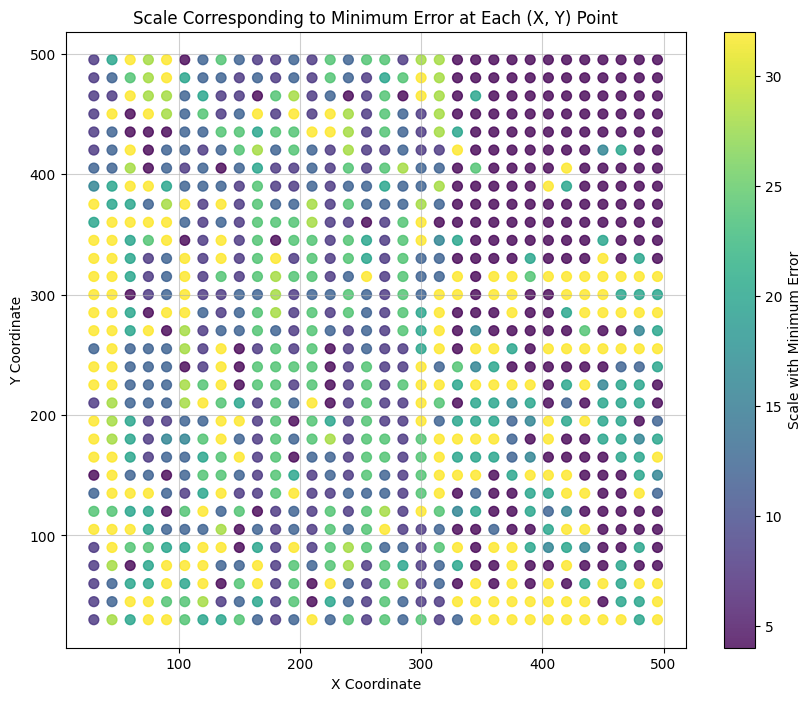

In [24]:

# Visualize the scales corresponding to the minimum error for each (x, y) point
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(min_errors_xy['x'], min_errors_xy['y'], c=min_errors_xy['scale'], cmap='viridis', s=50, alpha=0.8)
cbar = fig.colorbar(scatter)
cbar.set_label('Scale with Minimum Error')
ax.set_xlabel('X Coordinate')
ax.set_ylabel('Y Coordinate')
ax.set_title('Scale Corresponding to Minimum Error at Each (X, Y) Point')
plt.grid(True, alpha=0.6)
plt.show()

In [25]:
import numpy as np
plot_aq_ind, plot_aq_fn = distance_acq_fn(predicted_errors,
                                        beta=0,
                                        lambda_=1,
                                        sample_next_points=len(predicted_errors),
                                        exclude_indices=[])

print("Shape of plot_aq_fn:", plot_aq_fn.shape)
print("Shape of plot_aq_ind:", plot_aq_ind.shape)

Shape of plot_aq_fn: (8192,)
Shape of plot_aq_ind: (8192,)


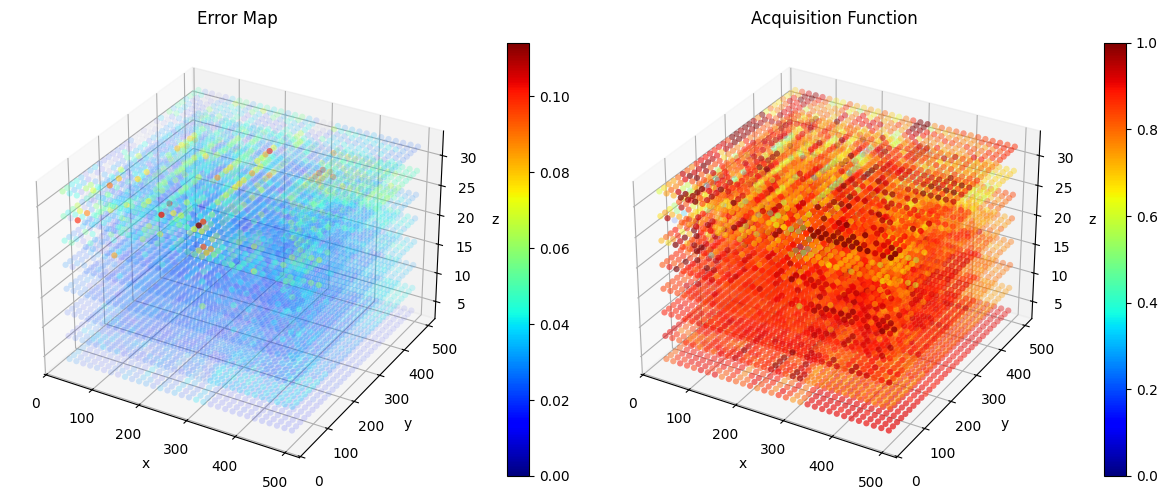

In [26]:
plot_error_prediction_3d(predicted_errors, plot_aq_fn, scale_coordinates, plot_aq_ind, alpha_scale = True, colormap = 'jet')

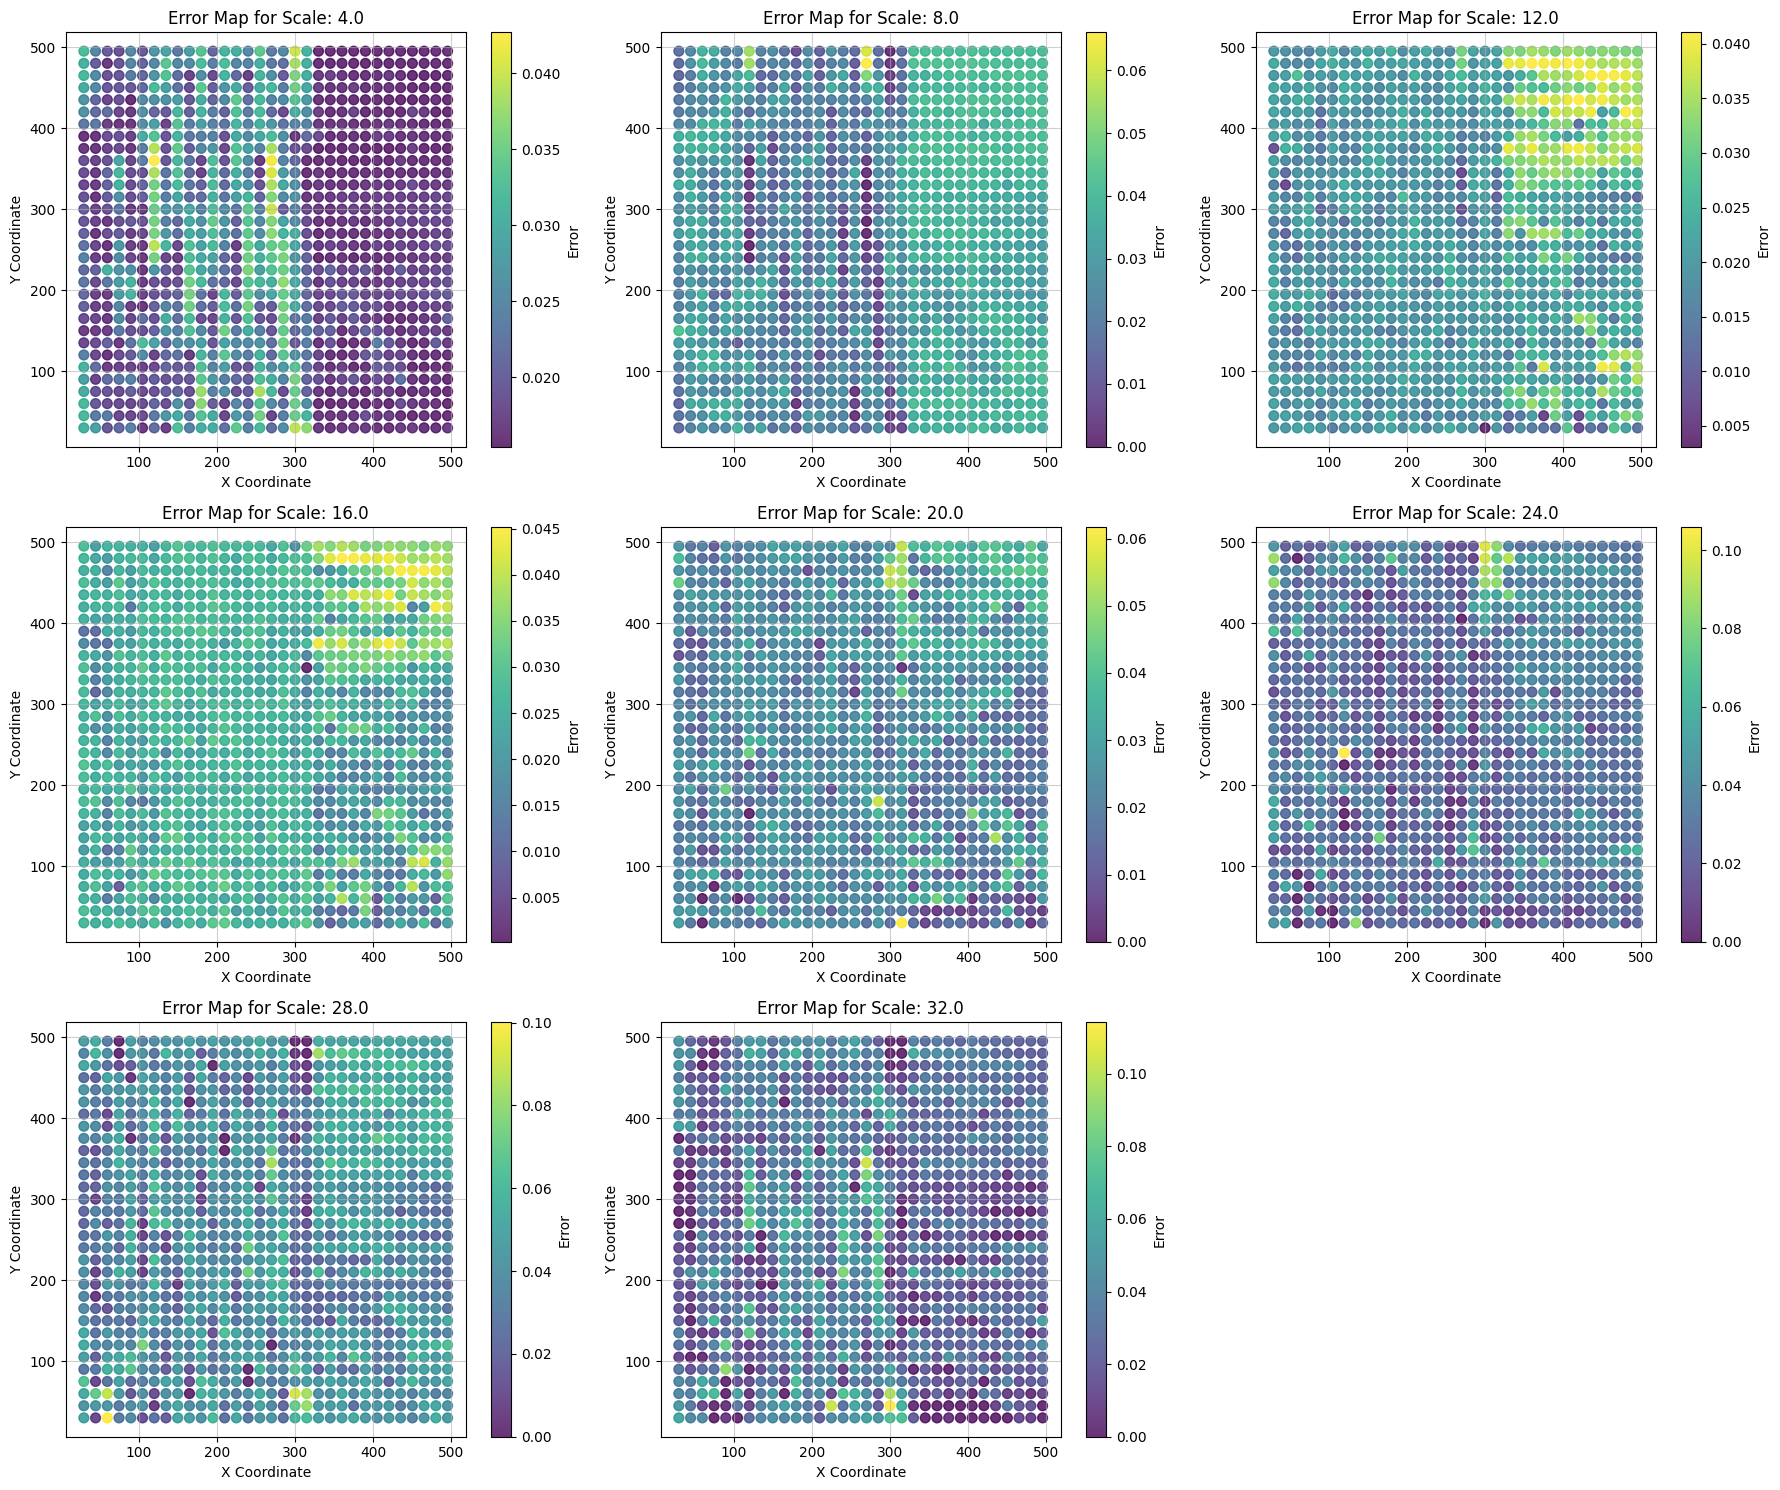

In [27]:
unique_scales = df_errors['scale'].unique()
unique_scales.sort()

# Determine optimal grid size for subplots
n_scales = len(unique_scales)
n_cols = 3  # Number of columns for subplots
n_rows = int(np.ceil(n_scales / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 6, n_rows * 5), squeeze=False)
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, scale in enumerate(unique_scales):
    ax = axes[i]
    scale_data = df_errors[df_errors['scale'] == scale]
    scatter = ax.scatter(scale_data['x'], scale_data['y'], c=scale_data['error'], cmap='viridis', s=50, alpha=0.8)
    fig.colorbar(scatter, ax=ax, label='Error')
    ax.set_title(f'Error Map for Scale: {scale}')
    ax.set_xlabel('X Coordinate')
    ax.set_ylabel('Y Coordinate')
    ax.grid(True, alpha=0.6)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()